Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

Loading dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent
METADATA_PATH = PROJECT_ROOT / "data" / "raw" / "PlantSeg" / "Metadata.csv"

df = pd.read_csv(METADATA_PATH)

EDA

In [3]:
df.head()

,Name,Index,Plant,Disease,Resolution,Label file,Mask ratio,URL,License,Split
0,apple_black_rot_1.jpg,0,Apple,apple black rot,640x480,apple_black_rot_1.png,0.040439,https://baijiahao.baidu.com/s?id=1592172448991...,CC-BY-NC,Training
1,apple_black_rot_11.jpg,0,Apple,apple black rot,1080x755,apple_black_rot_11.png,0.057550,http://dy.163.com/v2/article/detail/EJ3OGOG605...,CC-BY-NC,Training
2,apple_black_rot_12.jpg,0,Apple,apple black rot,1280x719,apple_black_rot_12.png,0.024791,http://baijiahao.baidu.com/s?id=16205160930871...,CC-BY-NC,Training
3,apple_black_rot_15.jpg,0,Apple,apple black rot,600x355,apple_black_rot_15.png,0.236169,http://www.360doc.cn/article/4310958_180040780...,CC-BY-NC,Training
4,apple_black_rot_156.jpg,0,Apple,apple black rot,219x294,apple_black_rot_156.png,0.054344,http://baijiahao.baidu.com/s?id=16352401074244...,CC-BY-NC,Training


In [4]:
#Dataset Dimentions
print(f"Shape : {df.shape}")
print(f"Columns : {df.shape[1]}") #can use df.columns to get the column names
print(f"Rows : {df.shape[0]}") #can use df.index to get the row names

Shape : (7774, 10)
Columns : 10
Rows : 7774


In [5]:
df.dtypes

Name              str
Index           int64
Plant             str
Disease           str
Resolution        str
Label file        str
Mask ratio    float64
URL               str
License           str
Split             str
dtype: object

In [6]:
#missing values
df.isnull().sum()

Name          0
Index         0
Plant         0
Disease       0
Resolution    0
Label file    0
Mask ratio    0
URL           0
License       0
Split         0
dtype: int64

Understand categorical variables

In [7]:
print("Unique plants:", df["Plant"].nunique())
print("Unique diseases:", df["Disease"].nunique())
print("Unique splits:", df["Split"].nunique())

Unique plants: 34
Unique diseases: 115
Unique splits: 3


In [8]:
df["Split"].value_counts()

Split
Training      5367
Test          1561
Validation     846
Name: count, dtype: int64

**Investigate class imbalance**
How balanced or imbalanced are the disease classes?

In [9]:
disease_counts = df["Disease"].value_counts()

print("Total diseases ", len(disease_counts))
print("Disease with highest count: ", disease_counts.max())
print("Disease with lowest count: ", disease_counts.min())
print("Average disease count : ", round(disease_counts.mean(),2))

Total diseases  115
Disease with highest count:  323
Disease with lowest count:  3
Average disease count :  67.6


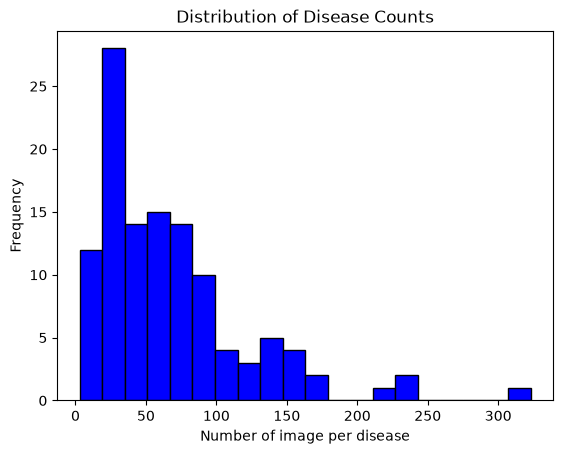

In [10]:
#plt.figure(figsize=(12,6))
plt.hist(disease_counts,bins=20, color='blue', edgecolor='black')
plt.title("Distribution of Disease Counts")
plt.xlabel("Number of image per disease")
plt.ylabel("Frequency")
plt.show()


Which plants are represented? Does the dataset contain a balanced number of images across different plants


In [11]:
plant_counts = df["Plant"].value_counts()

print("Total plants",len(plant_counts))
print("Top 10 plants", plant_counts.head(10))
print("Bottom 10 plants", plant_counts.tail(10))
print("Average plant count : ", round(plant_counts.mean(),2))
print("Plant with highest count :", plant_counts.max())
print("Plant with lowest count : ",plant_counts.min())

Total plants 34
Top 10 plants Plant
Wheat       1166
Tomato       667
Soybean      500
Corn         419
Citrus       416
Apple        402
Grape        400
Cucumber     383
Banana       354
Peach        287
Name: count, dtype: int64
Bottom 10 plants Plant
Broccoli       91
Cherry         91
Ginger         81
Raspberry      77
Lettuce        76
Maple          58
Cauliflower    53
Strawberry     49
Basil          41
Celery         40
Name: count, dtype: int64
Average plant count :  228.65
Plant with highest count : 1166
Plant with lowest count :  40


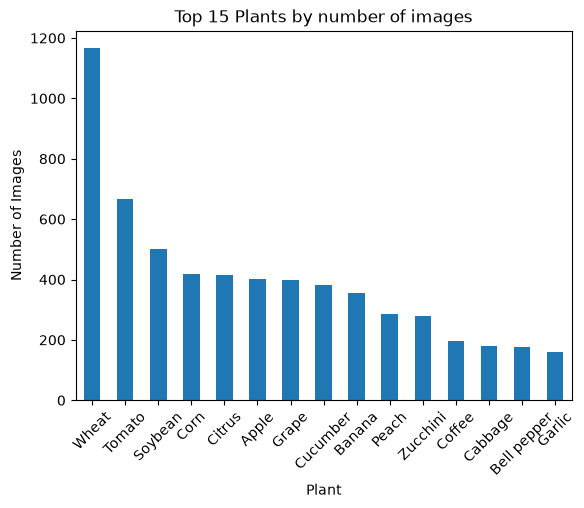

In [12]:
plant_counts.head(15).plot(kind='bar')
plt.title("Top 15 Plants by number of images")
plt.xlabel("Plant")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [13]:
plant_disease = pd.crosstab(df["Plant"], df["Disease"])

plant_disease.shape

(34, 115)

In [14]:
diseases_per_plant = df.groupby("Plant")["Disease"].nunique()

print(diseases_per_plant.sort_values(ascending=False).head(15))

Plant
Wheat          8
Tomato         7
Soybean        6
Banana         6
Plum           5
Blueberry      5
Peach          5
Apple          4
Corn           4
Bell pepper    4
Raspberry      4
Grape          4
Tobacco        4
Coffee         4
Zucchini       4
Name: Disease, dtype: int64


inspect the relationship

Rather than immediately making a giant 34 × 115 heatmap—which would be unreadable - we'll first ask a useful question:For each plant, which diseases actually occur in it?

In [15]:
plant_disease_list = (
    df.groupby("Plant")["Disease"]
      .unique()
)

for plant, diseases in plant_disease_list.items():
    print(f"\n{plant}:")
    print(", ".join(diseases))

#i notice that almost all the diseases are plant specific like the apple has diseases thet attack apple only and wheat has diseases that attact wheat only etc. But I won't say "every disease is exclusive to one plant" yet.


Apple:
apple black rot, apple mosaic virus, apple rust, apple scab

Banana:
banana anthracnose, banana black leaf streak, banana bunchy top, banana cigar end rot, banana cordana leaf spot, banana panama disease

Basil:
basil downy mildew

Bean:
bean halo blight, bean mosaic virus, bean rust

Bell pepper:
bell pepper bacterial spot, bell pepper blossom end rot, bell pepper frogeye leaf spot, bell pepper powdery mildew

Blueberry:
blueberry anthracnose, blueberry botrytis blight, blueberry mummy berry, blueberry rust, blueberry scorch

Broccoli:
broccoli alternaria leaf spot, broccoli downy mildew, broccoli ring spot

Cabbage:
cabbage alternaria leaf spot, cabbage black rot, cabbage downy mildew

Carrot:
carrot alternaria leaf blight, carrot cavity spot, carrot cercospora leaf blight

Cauliflower:
cauliflower alternaria leaf spot, cauliflower bacterial soft rot

Celery:
celery anthracnose, celery early blight

Cherry:
cherry leaf spot, cherry powdery mildew

Citrus:
citrus canker, citru

In [16]:
df.groupby("Plant")["Disease"].count().reset_index()

,Plant,Disease
0,Apple,402
1,Banana,354
2,Basil,41
3,Bean,144
4,Bell pepper,176
5,Blueberry,142
6,Broccoli,91
7,Cabbage,181
8,Carrot,105
9,Cauliflower,53


In [17]:
df.groupby("Plant")["Disease"].value_counts()

Plant     Disease                     
Apple     apple scab                      168
          apple rust                       98
          apple mosaic virus               73
          apple black rot                  63
Banana    banana black leaf streak        114
                                         ... 
Wheat     wheat leaf rust                  75
Zucchini  zucchini powdery mildew         133
          zucchini bacterial wilt          57
          zucchini yellow mosaic virus     56
          zucchini downy mildew            33
Name: count, Length: 115, dtype: int64

In [18]:
#Our current analysis shows strong plant-specificity, but we haven't formally verified that every disease belongs to exactly one plant.
#lets test this :

disease_plant_counts = df.groupby("Disease")["Plant"].nunique()

print("Diseases occurring on exactly one plant:",
      (disease_plant_counts == 1).sum())

print("Diseases occurring on multiple plants:",
      (disease_plant_counts > 1).sum())

print("\nDiseases occurring on multiple plants:")
print(disease_plant_counts[disease_plant_counts > 1])

Diseases occurring on exactly one plant: 115
Diseases occurring on multiple plants: 0

Diseases occurring on multiple plants:
Series([], Name: Plant, dtype: int64)


Lets visualise : How many images does each disease actually have?

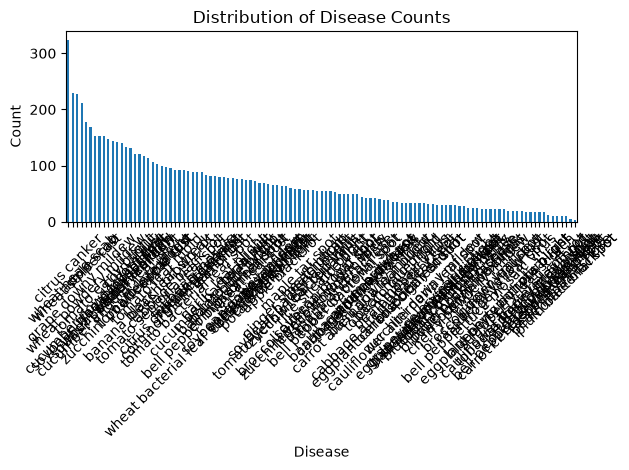

In [19]:
disease_counts.plot(kind="bar")
plt.title("Distribution of Disease Counts")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout() # it's used to automatically adjust subplot parameters so that your plots fit cleanly inside the figure area
plt.show()

In [20]:
#Let's properly analyze the distribution

disease_counts.describe()

count    115.000000
mean      67.600000
std       53.662656
min        3.000000
25%       29.000000
50%       55.000000
75%       89.000000
max      323.000000
Name: count, dtype: float64

__Image Characteristics Analysis__

In [21]:
from PIL import Image   #Python Imaging Library module adds extensive image processing capabilities to Python. discontinued in 2011
from pathlib import Path  # offers an object-oriented way to handle and manage filesystem paths across different operating systems
from collections import Counter  #provides high-performance, specialized container datatypes that serve as alternatives to the general-purpose built-in containers

image_dir = Path("../data/raw/PlantSeg/images")

image_sizes = []

#rglob() recursively search a directory and all of its subdirectories for files and folders that match a specific pattern
for image_path in image_dir.rglob("*.jpg"):
    try:
        with Image.open(image_path) as img:
            image_sizes.append(img.size)  #img.size returns a tuple (width, height)
    except Exception:
        pass  #ignore any errors that occur while opening the image

print("Total images checked:", len(image_sizes))
print("Unique image sizes:", len(set(image_sizes)))

print("\nMost common image sizes:")
for size, count in Counter(image_sizes).most_common(15):
    print(size, "→", count)

Total images checked: 7774
Unique image sizes: 3895

Most common image sizes:
(640, 480) → 149
(1024, 768) → 128
(600, 380) → 107
(1200, 900) → 79
(600, 400) → 73
(800, 600) → 72
(1200, 1600) → 61
(300, 225) → 60
(1280, 720) → 59
(600, 450) → 58
(768, 1024) → 56
(640, 853) → 53
(500, 375) → 49
(1200, 800) → 49
(1600, 1200) → 48


In [22]:
# Calculate aspect ratios

aspect_ratios = [width / height for width, height in image_sizes]

print("Minimum aspect ratio:", round(min(aspect_ratios), 2))
print("Maximum aspect ratio:", round(max(aspect_ratios), 2))

print("\nMost common aspect ratios:")

rounded_ratios = [round(ratio, 2) for ratio in aspect_ratios]

for ratio, count in Counter(rounded_ratios).most_common(15):
    print(ratio, "→", count)

Minimum aspect ratio: 0.34
Maximum aspect ratio: 4.5

Most common aspect ratios:
1.33 → 1445
1.5 → 843
0.75 → 765
1.0 → 313
1.78 → 290
0.67 → 172
1.51 → 154
1.58 → 151
1.34 → 128
1.49 → 112
1.55 → 96
0.56 → 90
1.52 → 78
1.48 → 69
1.61 → 69


In [23]:
# Find images with extreme aspect ratios

extreme_images = []

for image_path in image_dir.rglob("*.jpg"):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            ratio = width / height

            if ratio < 0.5 or ratio > 3:
                extreme_images.append(
                    (image_path.name, width, height, round(ratio, 2))
                )

    except Exception:
        pass

print("Number of extreme-ratio images:", len(extreme_images))

print("\nExamples:")
for item in extreme_images[:20]:
    print(item)

Number of extreme-ratio images: 36

Examples:
('banana_cigar_end_rot_Google_0101.jpg', 800, 1777, 0.45)
('blueberry_anthracnose_Bing_0145.jpg', 500, 114, 4.39)
('corn_rust_google_0071.jpg', 1440, 320, 4.5)
('rice_blast_google_0062.jpg', 242, 541, 0.45)
('apple_rust_78.jpg', 640, 1387, 0.46)
('apple_scab_62.jpg', 650, 1409, 0.46)
('apple_scab_65.jpg', 640, 1387, 0.46)
('banana_bunchy_top_Google_0109.jpg', 3600, 800, 4.5)
('citrus_canker_46.jpg', 640, 1422, 0.45)
('citrus_canker_google_0197.jpg', 1235, 2480, 0.5)
('corn_northern_leaf_blight_7.jpg', 478, 959, 0.5)
('corn_rust_google_0049.jpg', 2338, 597, 3.92)
('cucumber_powdery_mildew_51.jpg', 640, 1385, 0.46)
('garlic_rust_103.jpg', 159, 370, 0.43)
('grape_downy_mildew_87.jpg', 495, 1023, 0.48)
('potato_early_blight_google_0119.jpg', 750, 230, 3.26)
('rice_blast_17.jpg', 1056, 2280, 0.46)
('soybean_frog_eye_leaf_spot_Bing_0118.jpg', 583, 1200, 0.49)
('strawberry_anthracnose_10.jpg', 650, 1449, 0.45)
('tobacco_brown_spot_Bing_0015.jpg', 

What do these extreme images actually look like?

In [24]:
#path issue resolution

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(PROJECT_ROOT)

Current working directory:
c:\Users\Dell\Documents\Projects\AgriSense\notebooks

Project root:
c:\Users\Dell\Documents\Projects\AgriSense


In [25]:
image_dir = PROJECT_ROOT / "data" / "raw" / "PlantSeg" / "images"

print(image_dir)
print("Exists:", image_dir.exists())

c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images
Exists: True


In [26]:
#creating a lookup for actual file names and therir actual paths

image_lookup = {}

for image_path in image_dir.rglob("*.jpg"):
    image_lookup[image_path.name]=image_path

print("Images Found : ",len(image_lookup))



Images Found :  7774


In [27]:
file_name = extreme_images[0][0]  # Get the first extreme image's file name

print("File name:", file_name)
print("File path", image_lookup[file_name])

File name: banana_cigar_end_rot_Google_0101.jpg
File path c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images\test\banana_cigar_end_rot_Google_0101.jpg


Visual inspection

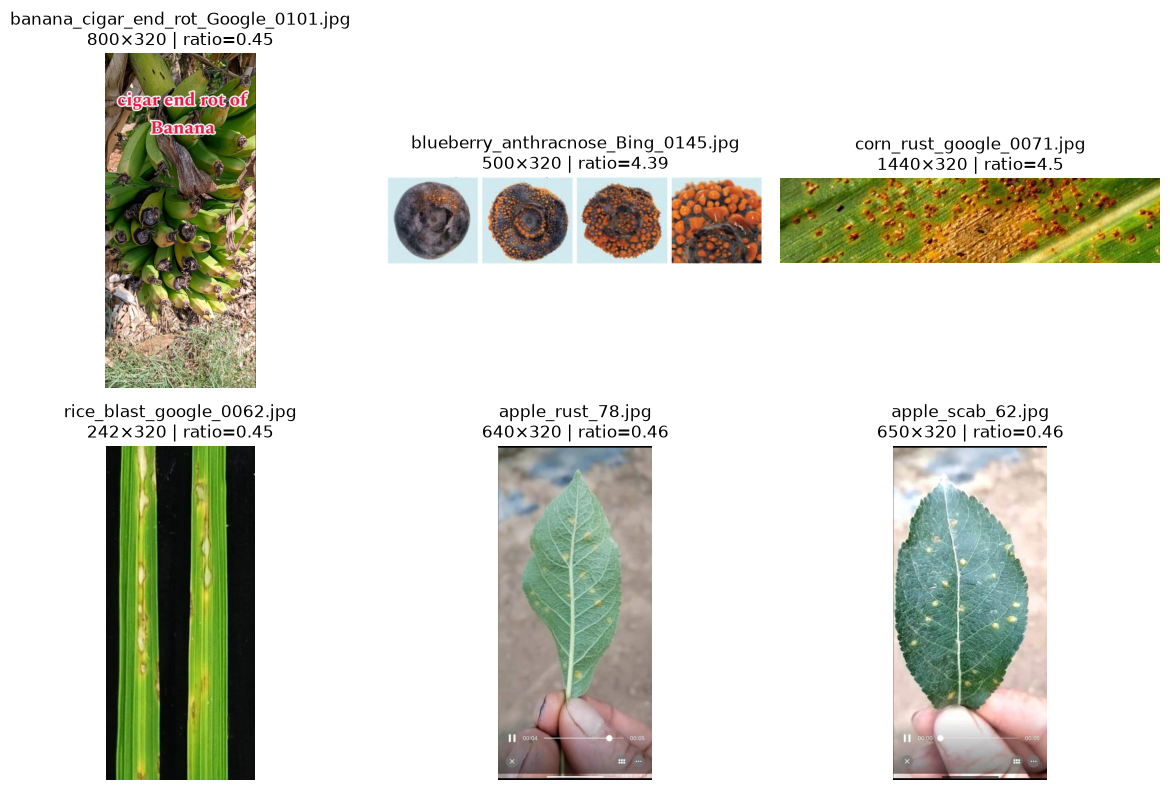

In [28]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax, item in zip(axes.ravel(), extreme_images[:6]):
    filename, width, heighr, ratio = item
    image_path = image_lookup.get(filename)
    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(f"{filename}\n{width}×{height} | ratio={ratio}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Are any images unreadable?

In [29]:
corrupted_images = []

for image_path in image_dir.rglob("*.jpg"):
    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:
        corrupted_images.append(
            (image_path.name, str(e))
        )

print("Total images checked:", len(list(image_dir.rglob("*.jpg"))))
print("Unreadable/corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for item in corrupted_images[:10]:
        print(item)

Total images checked: 7774
Unreadable/corrupted images: 0


Are the images RGB, grayscale, RGBA, etc.? If some images are grayscale (1 channel) or have an alpha channel (4 channels), our preprocessing pipeline needs to handle that consistently.

In [30]:
from collections import Counter

image_modes = Counter()

for image_path in image_dir.rglob("*.jpg"):
    try:
        with Image.open(image_path) as img:
            image_modes[img.mode] += 1
    except Exception:
        pass

print("Image color modes:")
for mode, count in image_modes.items():
    print(mode, "→", count)

Image color modes:
RGB → 7773
L → 1


Check metadata filenames against actual files

In [31]:
print(df.columns.tolist())

['Name', 'Index', 'Plant', 'Disease', 'Resolution', 'Label file', 'Mask ratio', 'URL', 'License', 'Split']


Check metadata ↔ image-file matching

In [32]:
# Check whether every metadata filename exists in the image directory

metadata_filenames = set(df["Name"])  #set because we're interested in membership: "Does this filename exist or not?" hence set operations

actual_filenames = set(image_lookup.keys())

missing_images = metadata_filenames - actual_filenames
extra_images = actual_filenames - metadata_filenames

print("Images referenced by metadata:", len(metadata_filenames))
print("Actual image files found:", len(actual_filenames))

print("\nImages missing from the filesystem:", len(missing_images))
print("Images not referenced by metadata:", len(extra_images))

Images referenced by metadata: 7774
Actual image files found: 7774

Images missing from the filesystem: 0
Images not referenced by metadata: 0


In [33]:
#we check whether the labels associated with those files make sense

print(df[["Name", "Plant", "Disease"]].head(20).to_string(index=False))

                           Name Plant         Disease
          apple_black_rot_1.jpg Apple apple black rot
         apple_black_rot_11.jpg Apple apple black rot
         apple_black_rot_12.jpg Apple apple black rot
         apple_black_rot_15.jpg Apple apple black rot
        apple_black_rot_156.jpg Apple apple black rot
        apple_black_rot_187.jpg Apple apple black rot
         apple_black_rot_28.jpg Apple apple black rot
         apple_black_rot_34.jpg Apple apple black rot
         apple_black_rot_38.jpg Apple apple black rot
          apple_black_rot_4.jpg Apple apple black rot
         apple_black_rot_44.jpg Apple apple black rot
         apple_black_rot_53.jpg Apple apple black rot
          apple_black_rot_6.jpg Apple apple black rot
         apple_black_rot_61.jpg Apple apple black rot
         apple_black_rot_74.jpg Apple apple black rot
          apple_black_rot_8.jpg Apple apple black rot
         apple_black_rot_80.jpg Apple apple black rot
apple_black_rot_google_0000.

In [34]:
#extract first word from the disease column and check if it matches the plant column

disease_plant = df["Disease"].str.split().str[0].str.lower()  # Convert to lowercase for case-insensitive comparison
metadata_plant = df["Plant"].str.lower()  # Convert to lowercase for case-insensitive comparison

#check for mismatches
mismatches = df[disease_plant != metadata_plant]

print("Total records:", len(df))
print("Plant-label mismatches:", len(mismatches))

if len(mismatches) > 0:
    print("\nExamples:")
    print(mismatches[["Name", "Plant", "Disease"]].head(20).to_string(index=False))

Total records: 7774
Plant-label mismatches: 208

Examples:
                                    Name       Plant                    Disease
bell_pepper_bacterial_spot_Bing_0000.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0001.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0004.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0006.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0009.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0010.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0013.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0027.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0029.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0031.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0042.jpg Bell pepper bell pep

In [35]:
#printing mismatch values

print(mismatches[["Name", "Plant", "Disease"]].head(30).to_string(index=False))

                                    Name       Plant                    Disease
bell_pepper_bacterial_spot_Bing_0000.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0001.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0004.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0006.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0009.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0010.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0013.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0027.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0029.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0031.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0042.jpg Bell pepper bell pepper bacterial spot
bell_pepper_bacterial_spot_Bing_0044.jpg

In [36]:
# Check whether each disease label starts with its corresponding plant name

plant_names = df["Plant"].str.lower().str.strip()
disease_names = df["Disease"].str.lower().str.strip()

matches = [
    disease.startswith(plant)
    for disease, plant in zip(disease_names, plant_names)
]

print("Total records:", len(df))
print("Disease labels starting with plant name:", sum(matches))
print("Records not following this pattern:", len(df) - sum(matches))

Total records: 7774
Disease labels starting with plant name: 7774
Records not following this pattern: 0


let's inspect the split distribution.

In [37]:
print(df["Split"].value_counts())
print("Percentages :- ")
print(df["Split"].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')  # Convert to string and append '%' sign

Split
Training      5367
Test          1561
Validation     846
Name: count, dtype: int64
Percentages :- 
Split
Training      69.04%
Test          20.08%
Validation    10.88%
Name: proportion, dtype: str


In [38]:
#disease x split distribution

disease_split_counts = pd.crosstab(df["Disease"], df["Split"])

print("Shape:", disease_split_counts.shape)

print("\nNumber of diseases represented in each split:")
print((disease_split_counts > 0).sum())   # Sum across columns to get the count of splits for each disease

Shape: (115, 3)

Number of diseases represented in each split:
Split
Test          114
Training      115
Validation    114
dtype: int64


In [39]:
#finding the diseases that are missing from validation and test splits

missing_from_validation = disease_split_counts[
    disease_split_counts["Validation"] == 0
].index.tolist()

missing_from_test = disease_split_counts[
    disease_split_counts["Test"] == 0
].index.tolist()

print("Missing from Validation:")
print(missing_from_validation)

print("\nMissing from Test:")
print(missing_from_test)

Missing from Validation:
['peach rust']

Missing from Test:
['coffee black rot']


In [40]:
#How many images does peach rust and coffee black rot actually have

important_diseases = df[
    df["Disease"].isin(["peach rust", "coffee black rot"])
]

print(
    important_diseases[
        ["Name", "Plant", "Disease", "Split"]
    ].to_string(index=False)
)

print("\nCounts by disease and split:")
print(
    important_diseases
    .groupby(["Disease", "Split"])
    .size()
)

                            Name  Plant          Disease      Split
  coffee_black_rot_Bing_0000.jpg Coffee coffee black rot   Training
  coffee_black_rot_Bing_0002.jpg Coffee coffee black rot   Training
coffee_black_rot_Google_0015.jpg Coffee coffee black rot Validation
        peach_rust_Bing_0010.jpg  Peach       peach rust   Training
        peach_rust_Bing_0015.jpg  Peach       peach rust   Training
        peach_rust_Bing_0019.jpg  Peach       peach rust   Training
        peach_rust_Bing_0020.jpg  Peach       peach rust   Training
        peach_rust_Bing_0001.jpg  Peach       peach rust       Test

Counts by disease and split:
Disease           Split     
coffee black rot  Training      2
                  Validation    1
peach rust        Test          1
                  Training      4
dtype: int64


In [41]:
print("Smallest validation class sizes:")
print(
    disease_split_counts["Validation"]
    .sort_values()
    .head(15)
)

print("\nSmallest test class sizes:")
print(
    disease_split_counts["Test"]
    .sort_values()
    .head(15)
)

Smallest validation class sizes:
Disease
peach rust                       0
carrot cercospora leaf blight    1
coffee black rot                 1
ginger leaf spot                 1
plum bacterial spot              1
tobacco frogeye leaf spot        1
celery anthracnose               1
broccoli ring spot               2
coffee brown eye spot            2
eggplant phytophthora blight     2
celery early blight              2
raspberry leaf spot              2
peach anthracnose                2
banana cigar end rot             2
bell pepper powdery mildew       2
Name: Validation, dtype: int64

Smallest test class sizes:
Disease
coffee black rot                    0
peach rust                          1
raspberry leaf spot                 1
raspberry gray mold                 2
peach anthracnose                   2
broccoli downy mildew               3
blueberry botrytis blight           3
broccoli ring spot                  3
celery anthracnose                  3
plum bacterial spot      

__Visual EDA__ Lets look at visul samples

In [42]:
# Select 12 different diseases and take one image from each

sample_df = (
    df.groupby("Disease", group_keys=False)
      .head(1)
      .sample(12, random_state=42)
      .reset_index()
)

print(
    sample_df[["Name", "Plant", "Disease"]]
    .to_string()
)

                                 Name   Plant                    Disease
0                   rice_blast_10.jpg    Rice                 rice blast
1   banana_anthracnose_Baidu_0004.jpg  Banana         banana anthracnose
2   coffee_berry_blotch_Bing_0000.jpg  Coffee        coffee berry blotch
3            peach_scab_Bing_0000.jpg   Peach                 peach scab
4            basil_downy_mildew_2.jpg   Basil         basil downy mildew
5     corn_northern_leaf_blight_1.jpg    Corn  corn northern leaf blight
6   plum_bacterial_spot_Bing_0026.jpg    Plum        plum bacterial spot
7       peach_brown_rot_Bing_0001.jpg   Peach            peach brown rot
8                    corn_smut_10.jpg    Corn                  corn smut
9             bean_halo_blight_12.jpg    Bean           bean halo blight
10          tomato_mosaic_virus_1.jpg  Tomato        tomato mosaic virus
11            cherry_leaf_spot_13.jpg  Cherry           cherry leaf spot


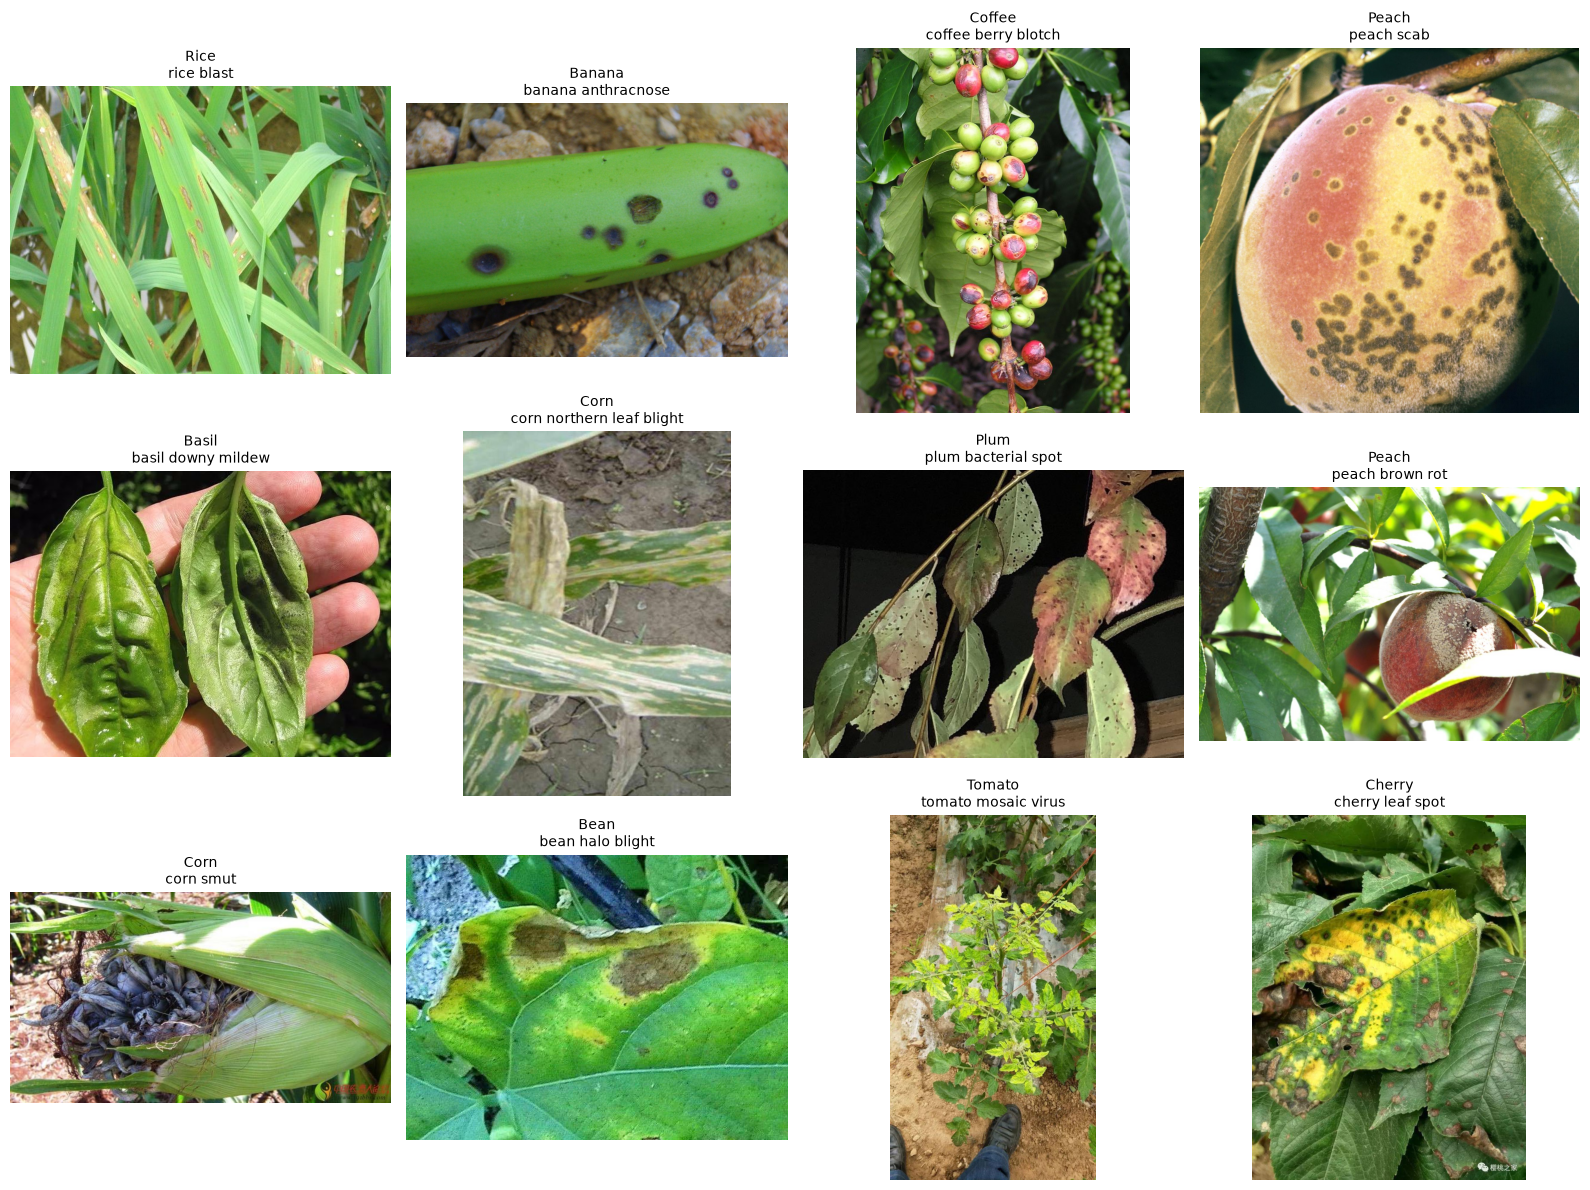

In [43]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):

    image_path = image_lookup.get(row["Name"])

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(
        f'{row["Plant"]}\n{row["Disease"]}',
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Check exact duplicate files

In [44]:
import hashlib

image_hashes = {}
duplicate_images = []

for image_path in image_dir.rglob("*.jpg"):

    with open(image_path, "rb") as f:   #Opens the current image file in Read Binary mode (required because images are binary data, not text)
        file_hash = hashlib.md5(f.read()).hexdigest()

    if file_hash in image_hashes:
        duplicate_images.append(
            (image_path.name, image_hashes[file_hash])
        )
    else:
        image_hashes[file_hash] = image_path.name

print("Unique image contents", len(image_hashes))
print("Exact duplicate files:", len(duplicate_images))

if duplicate_images:
    print("\nExamples:")
    for duplicate in duplicate_images[:10]:
        print(duplicate)

Unique image contents 7497
Exact duplicate files: 277

Examples:
('banana_black_leaf_streak_Bing_0015.jpg', 'banana_black_leaf_streak_banana black sigatoka (28).jpg')
('broccoli_ring_spot_Bing_0002.jpg', 'broccoli_alternaria_leaf_spot_Bing_0000.jpg')
('broccoli_ring_spot_Bing_0047.jpg', 'broccoli_alternaria_leaf_spot_Bing_0048.jpg')
('coffee_brown_eye_spot_Bing_0036.jpg', 'coffee_berry_blotch_Bing_0006.jpg')
('soybean_frog_eye_leaf_spot_Bing_0003.jpg', 'bell_pepper_frogeye_leaf_spot_Bing_0008.jpg')
('tobacco_brown_spot_Bing_0159.jpg', 'tobacco_blue_mold_Bing_0107.jpg')
('tomato_bacterial_leaf_spot_google_0087.jpg', 'eggplant_cercospora_leaf_spot_google_0030.jpg')
('tomato_early_blight_google_0163.jpg', 'grape_leaf_spot_google_0046.jpg')
('tomato_septoria_leaf_spot_google_0081.jpg', 'tomato_early_blight_google_0177.jpg')
('tomato_yellow_leaf_curl_virus_40.jpg', 'tomato_mosaic_virus_143.jpg')


In [45]:
#investigate duplicate pairs

for duplicate, original in duplicate_images[:10]:

    duplicate_info = df[df["Name"] == duplicate]
    original_info = df[df["Name"] == original]

    print("\nDuplicate:", duplicate)
    print(duplicate_info[["Name", "Plant", "Disease", "Split"]].to_string(index=False))

    print("Original:", original)
    print(original_info[["Name", "Plant", "Disease", "Split"]].to_string(index=False))


Duplicate: banana_black_leaf_streak_Bing_0015.jpg
                                  Name  Plant                  Disease Split
banana_black_leaf_streak_Bing_0015.jpg Banana banana black leaf streak  Test
Original: banana_black_leaf_streak_banana black sigatoka (28).jpg
                                                   Name  Plant                  Disease Split
banana_black_leaf_streak_banana black sigatoka (28).jpg Banana banana black leaf streak  Test

Duplicate: broccoli_ring_spot_Bing_0002.jpg
                            Name    Plant            Disease Split
broccoli_ring_spot_Bing_0002.jpg Broccoli broccoli ring spot  Test
Original: broccoli_alternaria_leaf_spot_Bing_0000.jpg
                                       Name    Plant                       Disease Split
broccoli_alternaria_leaf_spot_Bing_0000.jpg Broccoli broccoli alternaria leaf spot  Test

Duplicate: broccoli_ring_spot_Bing_0047.jpg
                            Name    Plant            Disease Split
broccoli_ring_spot

In [46]:
#Duplicate analysis

duplicate_analysis = []

for duplicate, original in duplicate_images:

    duplicate_row = df[df["Name"] == duplicate].iloc[0]
    original_row = df[df["Name"] == original].iloc[0]

    duplicate_analysis.append({
        "duplicate": duplicate,
        "original": original,
        "same_disease": duplicate_row["Disease"] == original_row["Disease"],
        "same_plant": duplicate_row["Plant"] == original_row["Plant"],
        "same_split": duplicate_row["Split"] == original_row["Split"]
    })

duplicate_df = pd.DataFrame(duplicate_analysis)

print("Total duplicate pairs:", len(duplicate_df))

print("\nSame disease:")
print(duplicate_df["same_disease"].value_counts())

print("\nDifferent disease:")
print((~duplicate_df["same_disease"]).sum())

print("\nDifferent split:")
print((~duplicate_df["same_split"]).sum())

Total duplicate pairs: 277

Same disease:
same_disease
True     174
False    103
Name: count, dtype: int64

Different disease:
103

Different split:
129


In [47]:
print(pd.crosstab(
    duplicate_df["same_disease"],
    duplicate_df["same_split"]
))

same_split    False  True 
same_disease              
False            54     49
True             75     99


In [48]:
problematic_duplicates = duplicate_df[
    (duplicate_df["same_disease"] == False) &
    (duplicate_df["same_split"] == False)
]

print("Critical duplicate pairs:", len(problematic_duplicates))

print(
    problematic_duplicates.head(20).to_string(index=False)
)

Critical duplicate pairs: 54
                                       duplicate                                         original  same_disease  same_plant  same_split
     bell_pepper_frogeye_leaf_spot_Bing_0011.jpg         bell_pepper_bacterial_spot_Bing_0002.jpg         False        True       False
     broccoli_alternaria_leaf_spot_Bing_0017.jpg                 tobacco_brown_spot_Bing_0003.jpg         False       False       False
     broccoli_alternaria_leaf_spot_Bing_0039.jpg                 tobacco_brown_spot_Bing_0044.jpg         False       False       False
                broccoli_ring_spot_Bing_0054.jpg    broccoli_alternaria_leaf_spot_Google_0005.jpg         False        True       False
    cabbage_alternaria_leaf_spot_google_0013.jpg cauliflower_alternaria_leaf_spot_google_0028.jpg         False       False       False
    cabbage_alternaria_leaf_spot_google_0075.jpg cauliflower_alternaria_leaf_spot_google_0061.jpg         False       False       False
cauliflower_alterna

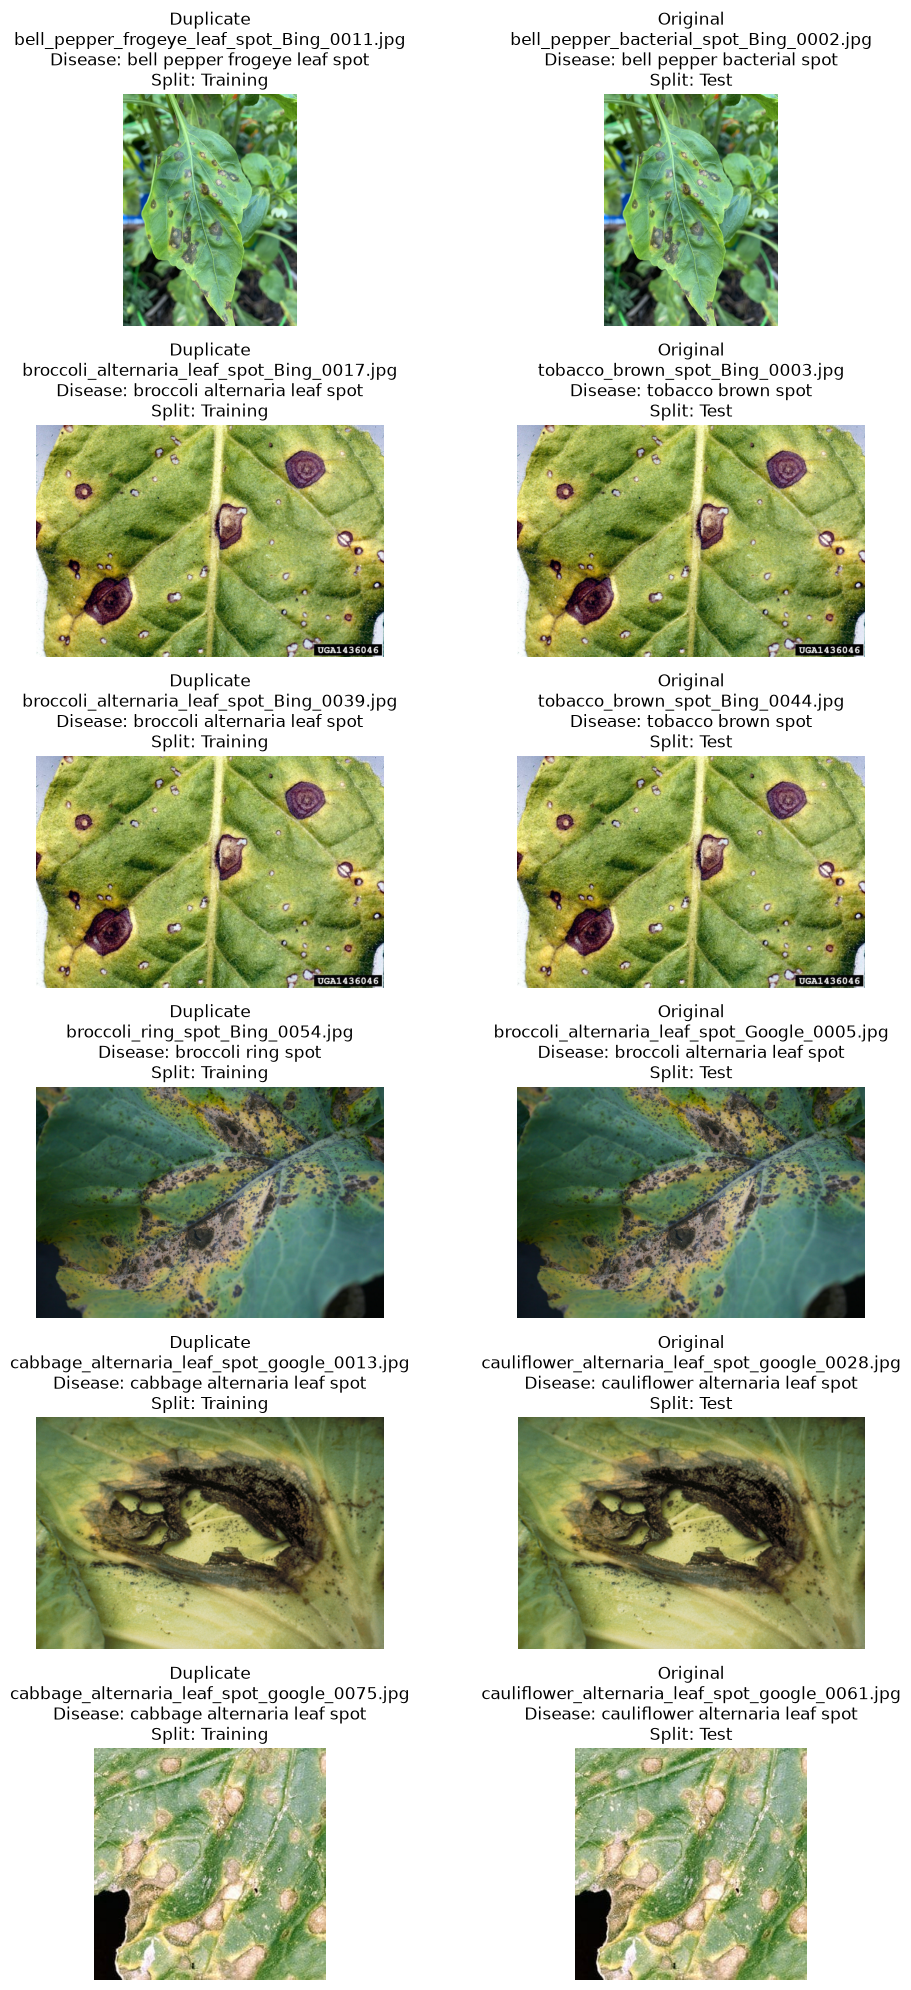

In [52]:
fig, axes = plt.subplots(6, 2, figsize=(10, 20))

for i, (_, row) in enumerate(problematic_duplicates.head(6).iterrows()):

    # Get the actual image paths from our lookup dictionary
    duplicate_path = image_lookup[row["duplicate"]]
    original_path = image_lookup[row["original"]]

    # Open the images
    duplicate_img = Image.open(duplicate_path)
    original_img = Image.open(original_path)

    # Left image
    axes[i, 0].imshow(duplicate_img)
    axes[i, 0].set_title(
        f'Duplicate\n'
        f'{row["duplicate"]}\n'
        f'Disease: {df.loc[df["Name"] == row["duplicate"], "Disease"].iloc[0]}\n'
        f'Split: {df.loc[df["Name"] == row["duplicate"], "Split"].iloc[0]}'
    )
    axes[i, 0].axis("off")

    # Right image
    axes[i, 1].imshow(original_img)
    axes[i, 1].set_title(
        f'Original\n'
        f'{row["original"]}\n'
        f'Disease: {df.loc[df["Name"] == row["original"], "Disease"].iloc[0]}\n'
        f'Split: {df.loc[df["Name"] == row["original"], "Split"].iloc[0]}'
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [54]:
#verify the file path 
print("Number of images in lookup:", len(image_lookup))

print(
    image_lookup.get(
        "bell_pepper_frogeye_leaf_spot_Bing_0011.jpg"
    )
)

Number of images in lookup: 7774
c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images\train\bell_pepper_frogeye_leaf_spot_Bing_0011.jpg


__Find unique images with multiple disease labels__

In [56]:
# Find image contents that have more than one disease label

hash_to_rows = {}

for image_path in image_dir.rglob("*.jpg"):

    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    row = df[df["Name"] == image_path.name].iloc[0]

    if file_hash not in hash_to_rows:
        hash_to_rows[file_hash] = []

    hash_to_rows[file_hash].append({
        "Name": row["Name"],
        "Plant": row["Plant"],
        "Disease": row["Disease"],
        "Split": row["Split"]
    })


conflicting_hashes = []

for file_hash, records in hash_to_rows.items():

    diseases = set(record["Disease"] for record in records)

    if len(diseases) > 1:
        conflicting_hashes.append(
            (file_hash, records, diseases)
        )

print(
    "Unique image contents with conflicting disease labels:",
    len(conflicting_hashes)
)

Unique image contents with conflicting disease labels: 98


In [57]:
# Find unique image contents that appear in multiple dataset splits

cross_split_images = []

for file_hash, records in hash_to_rows.items():

    splits = set(record["Split"] for record in records)

    if len(splits) > 1:
        cross_split_images.append(
            (file_hash, records, splits)
        )

print(
    "Unique image contents appearing in multiple splits:",
    len(cross_split_images)
)

Unique image contents appearing in multiple splits: 123


In [58]:
plant_counts = df["Plant"].value_counts()

print("Number of plant classes:", plant_counts.shape[0])

print("\nPlant distribution:")
print(plant_counts)

print("\nTop 5 plants by number of images:")
print(plant_counts.head(5))

print("\nPercentage represented by the largest plant class:")
print(
    round(
        plant_counts.iloc[0] / len(df) * 100,
        2
    ),
    "%"
)

Number of plant classes: 34

Plant distribution:
Plant
Wheat          1166
Tomato          667
Soybean         500
Corn            419
Citrus          416
Apple           402
Grape           400
Cucumber        383
Banana          354
Peach           287
Zucchini        279
Coffee          196
Cabbage         181
Bell pepper     176
Garlic          159
Potato          146
Bean            144
Squash          144
Blueberry       142
Tobacco         134
Plum            120
Carrot          105
Rice            105
Eggplant         92
Broccoli         91
Cherry           91
Ginger           81
Raspberry        77
Lettuce          76
Maple            58
Cauliflower      53
Strawberry       49
Basil            41
Celery           40
Name: count, dtype: int64

Top 5 plants by number of images:
Plant
Wheat      1166
Tomato      667
Soybean     500
Corn        419
Citrus      416
Name: count, dtype: int64

Percentage represented by the largest plant class:
15.0 %


## EDA Summary

### Dataset Structure
- Total image records: 7,774
- Metadata columns: 10
- Plant classes: 34
- Disease classes: 115
- No missing metadata values were detected.

### Dataset Split
- Training: 5,367 images (69.04%)
- Validation: 846 images (10.88%)
- Test: 1,561 images (20.08%)

### Class Distribution
- Plant distribution is imbalanced.
- Wheat is the most represented plant with 1,166 images (15.0% of the dataset).
- Disease distribution is also highly imbalanced.
- Disease class sizes range from 3 to 323 images.
- Mean images per disease: 67.6
- Median images per disease: 55

### Plant–Disease Relationship
- The dataset contains 115 disease classes across 34 plant classes.
- Disease labels are plant-specific in the current metadata.

### Image Properties
- 3,895 unique image resolutions were observed.
- Aspect ratios range from 0.34 to 4.50.
- 36 images were identified with extreme aspect ratios.
- 7,773 images are RGB and 1 image is grayscale.
- No corrupt image files were detected.

### Dataset Quality
- 7,497 unique image contents were identified using file hashing.
- 277 duplicate file occurrences were detected.
- 98 unique image contents are associated with multiple disease labels,
  indicating potential annotation conflicts.
- 123 unique image contents appear in multiple dataset splits,
  indicating potential data leakage.

### Key EDA Conclusion
The dataset is suitable for image classification, but it contains
class imbalance, variable image dimensions/aspect ratios, duplicate
images, potential conflicting annotations, and potential cross-split
image leakage. These issues must be addressed during dataset
preparation before model training.